## Identificación de patrones de abandono en estudiantes universitarios

### Problema de negocio

#####  Las instituciones de educación superior enfrentan el desafío del abandono estudiantil, lo que implica pérdidas económicas y afecta los indicadores académicos.

#####  A partir de la información disponible sobre los estudiantes, que incluye variables demográficas, socioeconómicas y de rendimiento académico, resulta relevante identificar qué factores podrían estar asociados tanto a la graduación como al abandono.

#####  En este contexto, el presente análisis busca responder el siguiente interrogante: 

#####  ¿Qué características presentan los estudiantes con mayor probabilidad de graduarse en la institución analizada?

### El set de datos

##### Se utiliza un dataset de estudiantes de educación superior que incluye información demográfica, socioeconómica y académica, con el objetivo de analizar factores asociados al abandono y la graduación.

##### El conjunto de datos contiene variables relacionadas con el rendimiento académico, la situación económica y el contexto personal de los estudiantes.

##### Fuente: https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success

### Primera mirada del dataset

In [2]:
#Leer archivo de performance de estudiantes
ruta = os.path.join(".", "Higher_Education_Portugal.csv") #construye ruta de archivos compatible con diferentes sistemas operativos.
df = pd.read_csv(ruta, sep=",") #Lee el archivo y lo guarda en un DataFrame de Pandas. 

In [21]:
# Import Libraries 
import os 

import pandas as pd
import numpy as np
import math

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn import preprocessing

In [60]:
# Configuración general
pd.set_option('display.max_columns',None) # para visualizar todas las columnas. 

#### Exploración inicial

In [61]:
print ('Información general del dataframe')
df.info()

Información general del dataframe
(4424, 35)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 35 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Nacionality                                     4424 non-null   int64  
 7   Mother's qualification                          4424 non-null   int64  
 8   Father's qualification                          4424 non-null   int64  
 

##### A partir del análisis de `df.info()` se observan las columnas del dataframe, la cantidad de valores nulos por columna y finalmente, el tipo de datos. 

##### En relación con los datos nulos, se puede ver que los datos se encuentran completos, lo cual facilita el análisis al no requerir tratamientos adicionales de imputación o eliminación de registros. No obstante, es importante considerar que la ausencia de valores nulos no garantiza la calidad total de los datos, por lo que se continuará evaluando su consistencia en las siguientes etapas.¶

##### En cuanto al tipo de datos, la mayoría de las variables del dataset son de tipo numérico (`int64` y `float64`). Si bien muchas variables aparecen como numéricas, varias de ellas representan categorías codificadas (por ejemplo: estado civil, género, tipo de curso), por lo que deberán ser tratadas como variables categóricas en el análisis. Por otro lado, las variables de tipo `float64` corresponden principalmente a métricas continuas, como calificaciones y variables macroeconómicas (tasa de desempleo, inflación y PIB), las cuales pueden ser analizadas directamente como variables numéricas.

In [5]:
df.sample(20) #Visualizar 20 registros del dataframe al azar

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
1995,1,1,5,10,1,1,1,18,14,1,3,1,0,0,1,0,0,18,0,0,6,8,6,11.333333,0,0,6,6,6,11.666667,0,7.6,2.6,0.32,Graduate
7,1,9,4,11,1,1,1,22,27,10,10,1,0,0,0,1,0,22,0,0,5,5,0,0.000000,0,0,5,5,0,0.000000,0,15.5,2.8,-4.06,Dropout
2876,1,12,1,13,1,1,3,3,3,5,5,0,0,1,0,0,0,54,1,0,7,7,0,0.000000,0,0,5,10,0,0.000000,0,12.4,0.5,1.79,Dropout
2640,2,12,1,7,1,12,1,22,27,10,10,0,0,0,1,1,0,36,0,0,5,0,0,0.000000,0,0,5,0,0,0.000000,0,16.2,0.3,-0.92,Dropout
391,1,12,1,12,1,1,1,1,14,6,4,0,1,0,1,0,0,26,0,0,7,11,5,11.200000,0,0,8,13,5,12.140000,0,16.2,0.3,-0.92,Enrolled
3694,1,8,1,2,1,1,1,1,1,10,10,1,0,0,1,1,0,18,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,12.7,3.7,-1.70,Dropout
1582,1,14,1,17,0,1,1,13,27,4,10,0,0,0,1,0,0,34,0,0,5,9,0,0.000000,0,0,5,10,1,11.000000,0,13.9,-0.3,0.79,Dropout
178,1,1,5,16,1,1,1,22,14,10,6,1,0,0,1,0,0,18,0,0,6,8,5,12.400000,0,0,6,12,5,10.400000,0,9.4,-0.8,-3.12,Dropout
2268,1,14,1,12,1,1,1,3,4,3,5,0,0,0,1,1,0,18,0,0,7,12,4,12.650000,0,0,7,10,3,10.666667,0,16.2,0.3,-0.92,Dropout
912,2,12,1,17,0,1,1,22,27,10,10,0,0,0,0,0,0,38,0,0,5,6,5,10.600000,0,0,5,9,2,11.000000,0,12.7,3.7,-1.70,Dropout


In [63]:
df.isnull().sum()

Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance                        0
Previous qualification                            0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrollment                                 0
International                                     0
Curricular u

##### A partir de la ejecución de df.isnull() se observa que no existen valores nulos en el dataset.
##### Esto indica que los datos se encuentran completos, lo cual facilita el análisis al no requerir tratamientos adicionales de imputación o eliminación de registros.
##### No obstante, es importante considerar que la ausencia de valores nulos no garantiza la calidad total de los datos, por lo que se continuará evaluando su consistencia en las siguientes etapas.

In [64]:
for col in df.columns:
    print(col, df[col].nunique())

Marital status 6
Application mode 18
Application order 8
Course 17
Daytime/evening attendance 2
Previous qualification 17
Nacionality 21
Mother's qualification 29
Father's qualification 34
Mother's occupation 32
Father's occupation 46
Displaced 2
Educational special needs 2
Debtor 2
Tuition fees up to date 2
Gender 2
Scholarship holder 2
Age at enrollment 46
International 2
Curricular units 1st sem (credited) 21
Curricular units 1st sem (enrolled) 23
Curricular units 1st sem (evaluations) 35
Curricular units 1st sem (approved) 23
Curricular units 1st sem (grade) 805
Curricular units 1st sem (without evaluations) 11
Curricular units 2nd sem (credited) 19
Curricular units 2nd sem (enrolled) 22
Curricular units 2nd sem (evaluations) 30
Curricular units 2nd sem (approved) 20
Curricular units 2nd sem (grade) 786
Curricular units 2nd sem (without evaluations) 10
Unemployment rate 10
Inflation rate 9
GDP 10
Target 3


##### Se analiza la cantidad de valores únicos por variable con el objetivo de identificar variables que no aporten variabilidad al análisis.

##### No se detectan variables con un único valor, por lo que todas las variables presentan información relevante para el análisis.

In [67]:
# Detecta si hay filas duplicadas. 
df.duplicated().sum()

np.int64(0)

#### Estadística descriptiva

In [6]:
print('Estadísticas descriptivas')
df.describe()

Estadísticas descriptivas


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,6.886980,1.727848,9.899186,0.890823,2.531420,1.254521,12.322107,16.455244,7.317812,7.819168,0.548373,0.011528,0.113698,0.880651,0.351718,0.248418,23.265145,0.024864,0.709991,6.270570,8.299051,4.706600,10.640822,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,5.298964,1.313793,4.331792,0.311897,3.963707,1.748447,9.026251,11.044800,3.997828,4.856692,0.497711,0.106760,0.317480,0.324235,0.477560,0.432144,7.587816,0.155729,2.360507,2.480178,4.179106,3.094238,4.843663,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,6.000000,1.000000,1.000000,1.000000,2.000000,3.000000,5.000000,5.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,19.000000,0.000000,0.000000,5.000000,6.000000,3.000000,11.000000,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,8.000000,1.000000,10.000000,1.000000,1.000000,1.000000,13.000000,14.000000,6.000000,8.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,20.000000,0.000000,0.000000,6.000000,8.000000,5.000000,12.285714,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,12.000000,2.000000,13.000000,1.000000,1.000000,1.000000,22.000000,27.000000,10.000000,10.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,25.000000,0.000000,0.000000,7.000000,10.000000,6.000000,13.400000,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,18.000000,9.000000,17.000000,1.000000,17.000000,21.000000,29.000000,34.000000,32.000000,46.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,70.000000,1.000000,20.000000,26.000000,45.000000,26.000000,18.875000,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


### Análisis exploratorio de datos

#### Análisis univariado

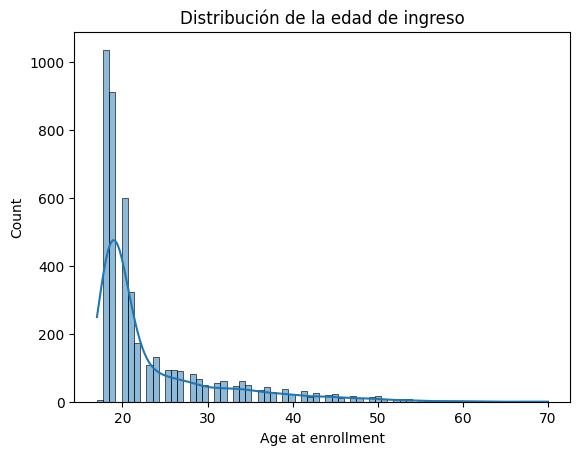

In [68]:
sns.histplot(data=df, x='Age at enrollment', kde=True)
plt.title('Distribución de la edad de ingreso')
plt.show()

#### Análisis bivariado

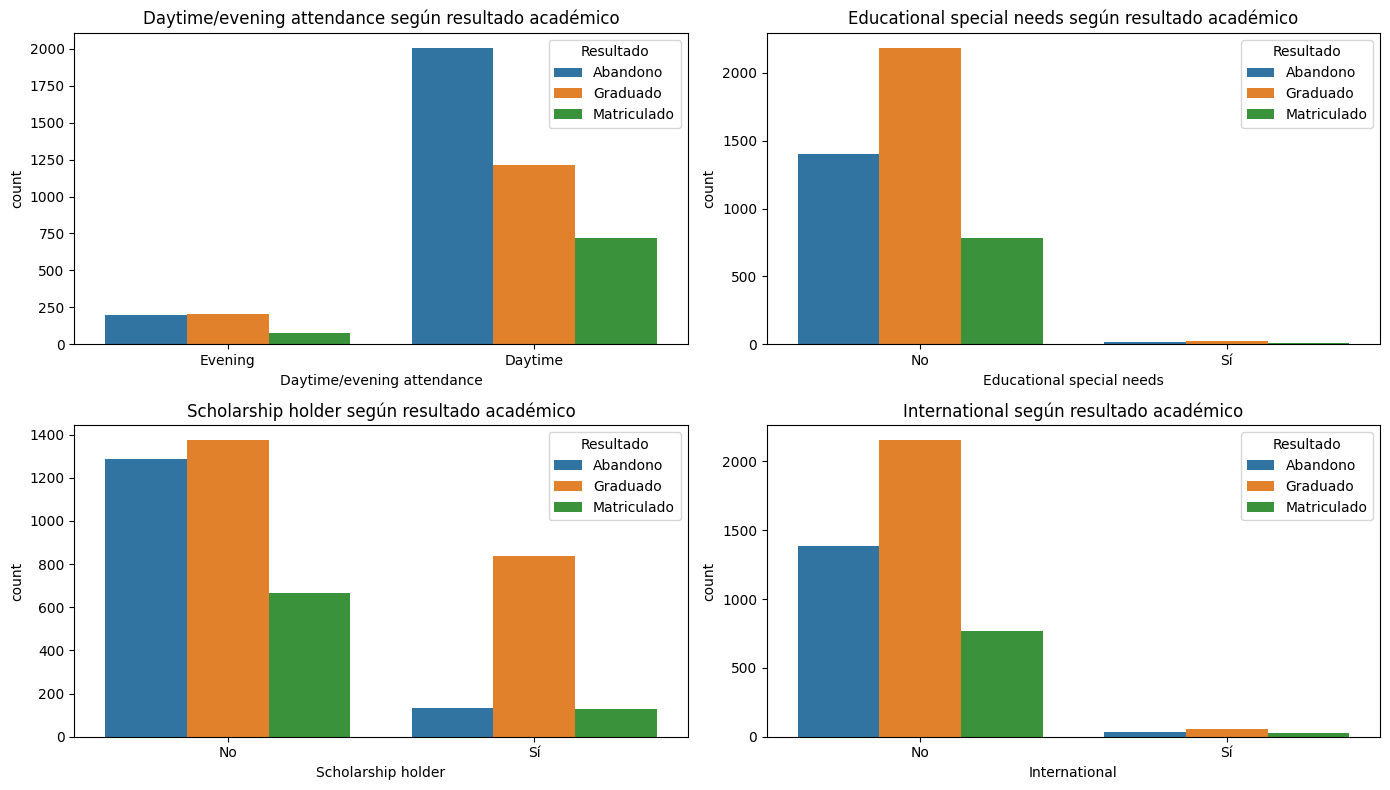

In [82]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

cols_cat = [
    'Daytime/evening attendance',
    'Educational special needs',
    'Scholarship holder',
    'International'
]

cols = 2
rows = math.ceil(len(cols_cat) / cols)

plt.figure(figsize=(14, 4 * rows))

for i, col in enumerate(cols_cat, 1):
    plt.subplot(rows, cols, i)
    sns.countplot(x=col, hue='Target', data=df)

    if col == 'Daytime/evening attendance':
        plt.xticks([0, 1], ['Evening', 'Daytime'])
    else:
        plt.xticks([0, 1], ['No', 'Sí'])

    plt.legend(title='Resultado', labels=['Abandono', 'Graduado', 'Matriculado'])
    plt.title(f'{col} según resultado académico')

plt.tight_layout()
plt.show()

##### A partir del análisis de las variables categóricas, se observan algunos patrones relevantes.

#####  En relación con la modalidad de cursada (diurna/nocturna), se observa que la mayoría de los estudiantes asiste en horario diurno. Al analizar el resultado académico, se identifica que en el grupo nocturno las proporciones de abandono y graduación son similares. Sin embargo, en el turno diurno se observan diferencias más marcadas entre ambos resultados. Cabe destacar que el número de estudiantes en modalidad nocturna es considerablemente menor, por lo que los resultados deben interpretarse con cautela.

##### En el caso de Educational_special_needs e International, no se observan patrones claros, aunque presentan menor cantidad de casos, lo que dificulta extraer conclusiones firmes.

##### Por otro lado, variables como Scholarship_holder muestran diferencias más marcadas, lo que podría indicar una relación con el desempeño académico.

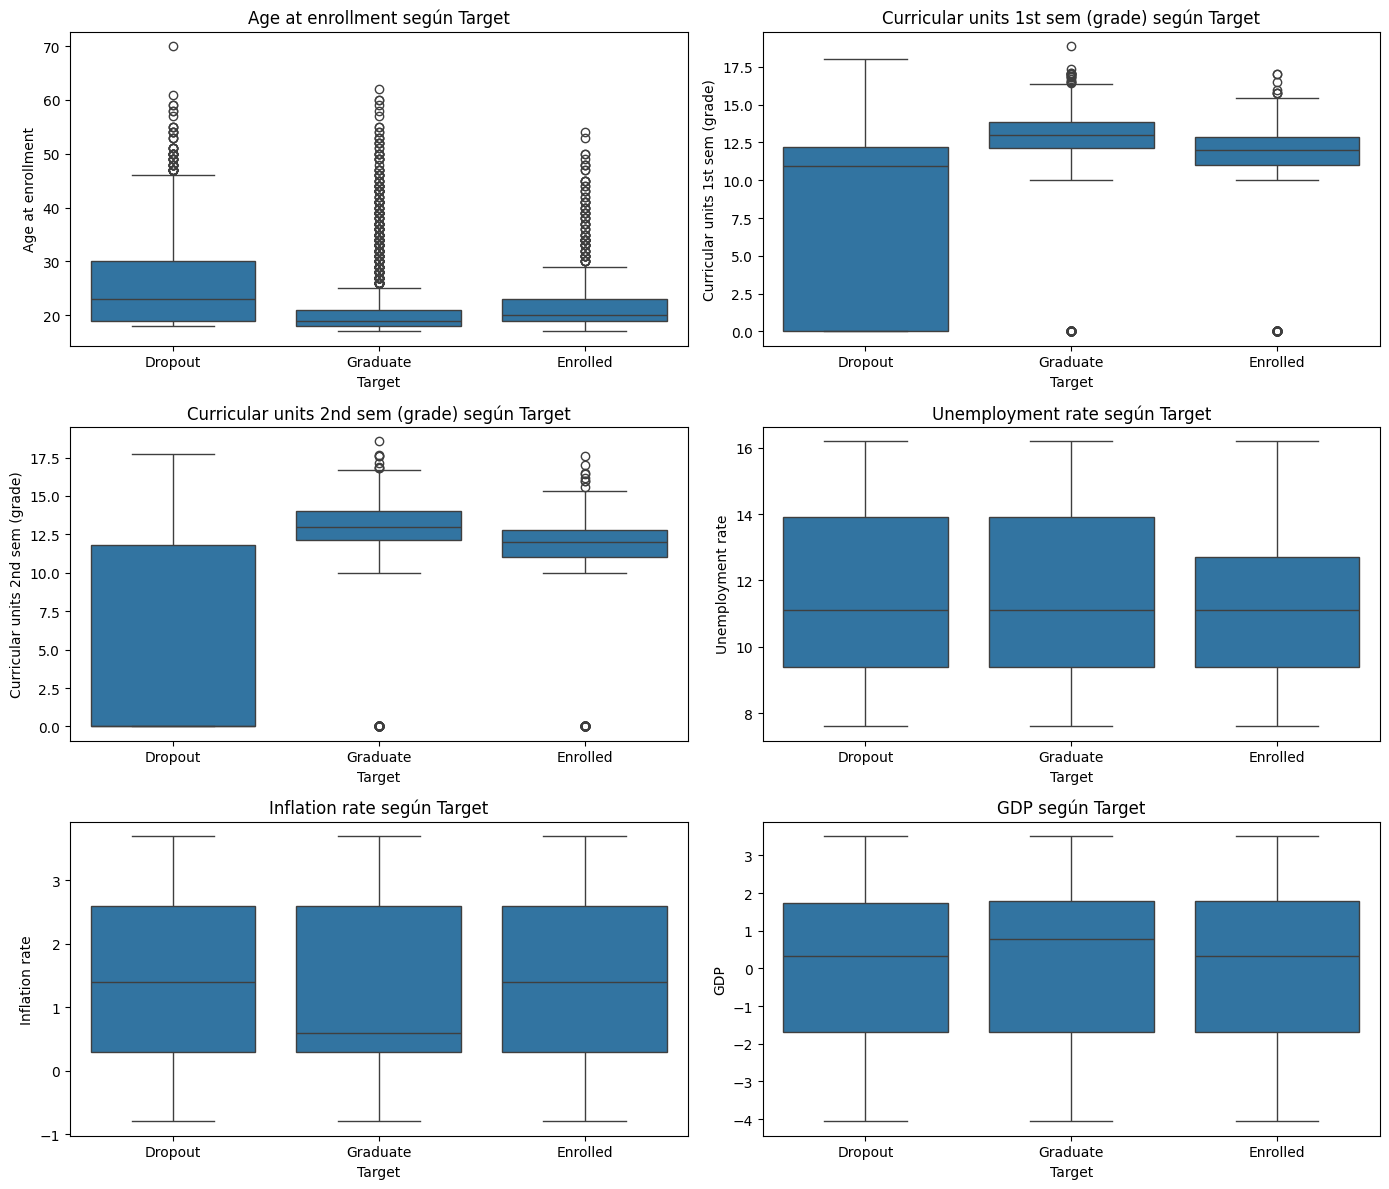

In [59]:
cols_numericas_reales = [
    'Age at enrollment',
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (grade)',
    'Unemployment rate',
    'Inflation rate',
    'GDP'
]

cols = 2
rows = math.ceil(len(cols_numericas_reales) / cols)

plt.figure(figsize=(14, 4 * rows))

for i, col in enumerate(cols_numericas_reales, 1):
    plt.subplot(rows, cols, i)
    sns.boxplot(x='Target', y=col, data=df)
    plt.title(f'{col} según Target')

plt.tight_layout()
plt.show()

##### Si bien la mayoría de los estudiantes que se gradúan se concentra en edades más tempranas, también se observa un número considerable de casos de estudiantes que ingresan a mayor edad y logran completar sus estudios. Esto sugiere que la edad de ingreso, por sí sola, no determina el resultado académico.

##### Las variables relacionadas con el rendimiento académico muestran un patrón consistente a lo largo del tiempo. Tanto en el primer como en el segundo semestre, los estudiantes que abandonan presentan calificaciones significativamente más bajas, mientras que aquellos que se gradúan muestran valores más elevados y concentrados. Esta consistencia refuerza la idea de que el desempeño académico es un factor fuertemente asociado al resultado académico.


##### Las variables macroeconómicas analizadas, como la tasa de desempleo, inflación y el PIB, no muestran diferencias significativas entre los distintos grupos de estudiantes. Las distribuciones presentan una alta superposición, lo que sugiere que estos factores no están fuertemente asociados al resultado académico en este caso.

### Transformación de variables

##### Se realizan transformaciones sobre algunas variables con el objetivo de facilitar su interpretación y preparación para un eventual modelo predictivo.

##### Se crea una variable binaria (`isSingle`) a partir del estado civil, donde se asigna el valor 1 a los estudiantes solteros y 0 al resto.

##### Esta transformación permite simplificar el análisis de esta variable, facilitando la comparación entre estudiantes solteros y quienes no lo son, y su posible relación con el abandono académico.

In [6]:
# 1 = soltero, 0 = resto
df['isSingle'] =  (df['Marital status'] == 1).astype(int) 

##### Se agrupan los distintos tipos de ingreso a la institución en categorías más generales mediante la creación de la variable `tipo_ingreso`.

##### Dado que la variable original (`Application mode`) contiene múltiples valores codificados, se opta por simplificarla en cuatro grupos: ingreso directo, traslado o segunda carrera, adulto/técnico y otros.

#####  Esta transformación permite facilitar la interpretación y el análisis de los datos, evitando trabajar con categorías demasiado fragmentadas.

##### Posteriormente, se aplica One-Hot Encoding sobre la nueva variable, generando variables binarias que permiten incorporar esta información de forma adecuada en el análisis.

In [7]:
# Agrupa tipos de ingreso en categorías más interpretables
# Aplica One-Hot Encoding para generar variables binarias

def agrupar_ingreso(modo):
    if modo in [1, 17, 18]:
        return 'Directo'
    elif modo in [7, 42, 43, 51, 57]:
        return 'Traslado_Segunda_Carrera'
    elif modo in [39, 44, 53]:
        return 'Adulto_Tecnico'
    else:
        return 'Otros'

# Crea la nueva columna
df['tipo_ingreso'] = df['Application mode'].apply(agrupar_ingreso)

# Aplica One-Hot Encoding
df= pd.get_dummies(df, columns=['tipo_ingreso'], prefix='ing',prefix_sep='_',dtype = int, drop_first=True)

##### Se filtran los registros correspondientes a estudiantes con estado "Enrolled", manteniendo únicamente aquellos que han finalizado su trayectoria como "Dropout" o "Graduate". Esta decisión permite trabajar con resultados finales claramente definidos, evitando la ambigüedad de estudiantes que aún se encuentran en curso.
##### Posteriormente, se transforma la variable objetivo (`Target`) en una variable binaria, asignando 0 a los casos de abandono y 1 a los de graduación.


In [87]:
df = df[df['Target'] != 'Enrolled'].copy()

df['Target'] = df['Target'].map({
    'Dropout': 0,
    'Graduate': 1
})

df['Target'] = df['Target'].astype(int)

print(df['Target'].unique())
print(df['Target'].dtype)

[0 1]
int64


##### Se analiza la relación entre el orden de elección de la carrera (`Application order`) y la variable objetivo, observando diferencias en la proporción de abandono y graduación según esta variable.

##### A partir de este análisis, se decide agrupar los valores en dos categorías: prioridad media-alta (primeras elecciones) y baja prioridad (elecciones posteriores).

##### Esta transformación permite simplificar la variable original y facilitar su interpretación en relación con el abandono académico.

##### Posteriormente, se aplica codificación para transformar esta nueva variable en formato numérico, permitiendo su uso en el análisis.

In [88]:
imp_app_order = df.groupby(['Application order'])['Target'].mean()
print(df['Application order'].value_counts().sort_index())

def agrupar_prioridad_eleccion(eleccion):
    if eleccion in [0, 1, 2, 3]:
        return 'Prioridad Medio Alta'
    else:
        return 'Baja Prioridad'

# Crear nueva variable
df['Application_order_update'] = df['Application order'].apply(agrupar_prioridad_eleccion)

# Mapear directamente a 0 y 1
df['Application_order_update'] = df['Application_order_update'].map({
    'Baja Prioridad': 0,
    'Prioridad Medio Alta': 1
})

display(df)

Application order
0       1
1    2461
2     451
3     249
4     218
5     129
6     121
Name: count, dtype: int64


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target,Application_order_update
0,1,8,5,2,1,1,1,13,10,6,10,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,0,0
1,1,6,1,11,1,1,1,1,3,4,4,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,1,1
2,1,1,5,5,1,1,1,22,27,10,10,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,0,0
3,1,8,2,15,1,1,1,23,27,6,4,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,1,1
4,2,12,1,3,0,1,1,22,28,10,10,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,1,1,6,15,1,1,1,1,1,6,5,0,0,0,1,1,0,19,0,0,6,7,5,13.600000,0,0,6,8,5,12.666667,0,15.5,2.8,-4.06,1,0
4420,1,1,2,15,1,1,19,1,1,10,10,1,0,1,0,0,0,18,1,0,6,6,6,12.000000,0,0,6,6,2,11.000000,0,11.1,0.6,2.02,0,1
4421,1,1,1,12,1,1,1,22,27,10,10,1,0,0,1,0,1,30,0,0,7,8,7,14.912500,0,0,8,9,1,13.500000,0,13.9,-0.3,0.79,0,1
4422,1,1,1,9,1,1,1,22,27,8,5,1,0,0,1,0,1,20,0,0,5,5,5,13.800000,0,0,5,6,5,12.000000,0,9.4,-0.8,-3.12,1,1


##### Se crea una variable binaria (`isInternational`) para distinguir entre estudiantes nacionales y extranjeros.

##### Dado que la variable original (`Nacionality`) presenta múltiples categorías con baja frecuencia, se opta por simplificarla en una variable binaria que permite capturar la información relevante de manera más clara. En consecuencia, la variable original es descartada para evitar redundancia y facilitar el análisis.

In [89]:
df['isInternational'] = (df['Nacionality'] != 1).astype(int)

##### Las variables `Mother's qualification` y `Father's qualification` representan el nivel educativo de los padres, codificado en múltiples categorías.

##### Dado que estas variables presentan una gran cantidad de valores y su interpretación detallada requiere información adicional, se decide mantenerlas sin transformaciones en esta etapa para evitar posibles errores.

##### No obstante, estas variables podrían ser exploradas posteriormente para evaluar su posible relación con el abandono académico.

##### La variable `Displaced` indica si el estudiante ha debido trasladarse de su lugar de origen para cursar sus estudios.

##### Este factor podría estar relacionado con el abandono académico, ya que el desarraigo puede influir en la adaptación, el entorno social y los recursos disponibles para el estudiante.

##### Dado que la variable se encuentra correctamente codificada en formato binario, no requiere transformaciones adicionales.

In [16]:
#0 no tiene deuda, 1 tiene deuda
df['Debtor'].value_counts()

Debtor
0    3217
1     413
Name: count, dtype: int64

In [18]:
df.groupby('Debtor')['Target'].mean()
# df.groupby('Tuition fees up to date')['Target'].mean()

Debtor
0    0.655269
1    0.244552
Name: Target, dtype: float64

In [ ]:
# El gráfico muestra el rendimiento de los estudiantes según género. 
fig, ax = plt.subplots(figsize=(6,6))
materias = ['math score', 'reading score', 'writing score']
materias_agrup = df.groupby(['gender'])[materias].mean()
materias_agrup.plot.bar(ax = ax, title ='Rendimiento académico por género', legend = True)
ax.legend(title="Materias", loc='best')
plt.xticks(rotation=0)
plt.show()


##### Se agrupa la variable `Age at enrollment` en rangos etarios con el objetivo de facilitar su interpretación en el análisis.

##### Se definen tres grupos: jóvenes (hasta 21 años), adultos jóvenes (entre 22 y 30 años) y adultos (mayores de 30 años).

##### Esta transformación permite analizar posibles diferencias en el abandono académico según la etapa de vida del estudiante.

In [21]:
def agrupar_edad(x):
    if x <= 21:
        return 'Joven'
    elif x <= 30:
        return 'Adulto joven'
    else:
        return 'Adulto'

df['grupo_edad'] = df['Age at enrollment'].apply(agrupar_edad)

In [ ]:
# Se aplica One-Hot Encoding para la columna relativa a la etnia
# El prefijo ayuda a saber de dónde venía la columna en tu portfolio

df= pd.get_dummies(df, columns=['race/ethnicity'], prefix='etnia',drop_first=True,dtype = int)

print(df.sample(10))

In [ ]:
df.dtypes
# df_model = 

In [ ]:
# Se crea el dataframe solo con los datos enteros y float
df_model = df.select_dtypes(include=['int', 'float'])
display(df_model)

In [ ]:
df_model = df_model.drop(columns=['reading score','writing score','Promedio_Gral'], axis=1)

In [ ]:
X = df_model.drop(columns=['math score'])
Y = df_model['math score']

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42)

In [ ]:
# Estandarizar los datos de entrenamiento
standardizer = preprocessing.StandardScaler()
X_train_scaled = standardizer.fit_transform(X_train)
X_test_scaled = standardizer.transform(X_test)

In [ ]:
display (X_train_scaled)

In [ ]:
#Se entrena el modelo
from sklearn.linear_model import LinearRegression
modelo = LinearRegression()
modelo.fit(X_train_scaled, Y_train)
modelo.score(X_train_scaled, Y_train)

In [ ]:
from sklearn.metrics import mean_absolute_error

Y_pred = modelo.predict(X_test_scaled)
mae = mean_absolute_error(Y_test, Y_pred)
print(f"El modelo se equivoca, en promedio, por {mae:.2f} puntos.")

In [ ]:
import pandas as pd

# Creamos el DataFrame 'importancia'
# X.columns contiene las variables, # modelo.coef_ contiene los pesos numéricos que calculó la Regresión

importancia = pd.DataFrame({
    'Factor': X.columns,
    'Peso (Impacto)': modelo.coef_
})

# Se ordena de mayor a mayor impacto para que el gráfico sea legible
importancia = importancia.sort_values(by='Peso (Impacto)', ascending=False)

print(importancia)

#### El análisis de regresión lineal permitió identificar los factores que más influyen en el desempeño matemático de los estudiantes.
#####  Impacto Socioeconómico: El tipo de almuerzo resultó ser la variable con mayor peso predictivo ($+5.45$ puntos), confirmando que las condiciones materiales son determinantes para el aprendizaje.
##### Contexto Étnico-Cultural: Se observa una ventaja significativa en el Grupo E ($+3.41$), lo que abre la puerta a investigar qué prácticas pedagógicas o familiares en este grupo fomentan el éxito en exactas.
#####  Intervención Pedagógica: El curso de preparación presenta un coeficiente negativo ($-2.93$), lo que sugiere que podría estar siendo utilizado como medida remedial para alumnos con rezago previo, más que como una herramienta de aceleración.

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Peso (Impacto)', y='Factor', data=importancia)
plt.title('Impacto de las Variables en la Nota de Matemáticas')
plt.xlabel('Peso del Coeficiente (Estandarizado)')
plt.ylabel('Variable Socio-Demográfica')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### Conclusiones

##### El análisis exploratorio de datos permitió identificar algunos factores relevantes asociados al abandono y la graduación de los estudiantes.

##### En particular, las variables relacionadas con el rendimiento académico muestran una asociación clara con el resultado académico. Tanto en el primer como en el segundo semestre, los estudiantes que abandonan presentan, en promedio, calificaciones más bajas, mientras que aquellos que se gradúan muestran un mejor desempeño. 

##### En relación con la edad de ingreso, se observa que los estudiantes presentan distintos intervalos etarios, con una mayor concentración en edades tempranas, aunque también existen casos de estudiantes mayores que logran graduarse. Esto indica que la edad, si bien puede influir, no constituye un factor determinante per se. 

##### Por otro lado, algunas variables categóricas muestran diferencias moderadas, como en el caso de la condición de beca, mientras que otras, como la modalidad de cursada, necesidades educativas especiales o la nacionalidad del estudiante, no presentan patrones claros o deben interpretarse con cautela debido al tamaño de muestra.

##### Finalmente, las variables macroeconómicas analizadas no evidencian una relación significativa con el resultado académico, lo que sugiere un menor impacto en este contexto.